# Probability Distributions

This notebook demonstrates:

- Discrete and continuous random variables
- Probability Mass Function (PMF)
- Probability Density Function (PDF)
- Cumulative Distribution Function (CDF)
- Relationship between PDF and CDF
- Common probability distributions

# Probability Distributions

This notebook demonstrates:

- Discrete and continuous random variables
- Probability Mass Function (PMF)
- Probability Density Function (PDF)
- Cumulative Distribution Function (CDF)
- Relationship between PDF and CDF
- Common probability distributions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

outcomes = np.arange(1, 7)
probabilities = np.full(6, 1 / 6)

print("Outcomes:", outcomes)
print("Probabilities:", probabilities)
print("Total probability:", probabilities.sum())

Outcomes: [1 2 3 4 5 6]
Probabilities: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Total probability: 0.9999999999999999


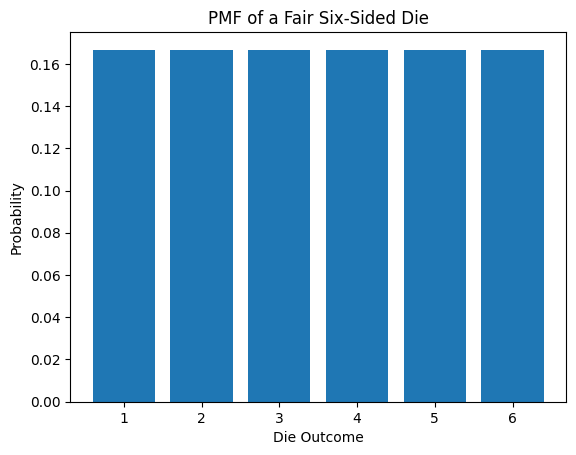

In [2]:
plt.bar(outcomes, probabilities)

plt.xlabel("Die Outcome")
plt.ylabel("Probability")
plt.title("PMF of a Fair Six-Sided Die")

plt.xticks(outcomes)
plt.show()

## PMF

For a discrete random variable:

$$
P(X=x)
$$

gives the probability of a particular value.

A valid PMF satisfies:

$$
P(X=x)\geq0
$$

and:

$$
\sum_xP(X=x)=1
$$

## CDF of a Discrete Random Variable

The CDF gives the cumulative probability:

$$
F(x)=P(X\leq x)
$$

For a fair die:

$$
P(X\leq2)
=
P(X=1)+P(X=2)
=
\frac{2}{6}
=
\frac{1}{3}
$$

In [3]:
cdf = np.cumsum(probabilities)

for x, value in zip(outcomes, cdf):
    print(f"P(X <= {x}) = {value:.4f}")

P(X <= 1) = 0.1667
P(X <= 2) = 0.3333
P(X <= 3) = 0.5000
P(X <= 4) = 0.6667
P(X <= 5) = 0.8333
P(X <= 6) = 1.0000


In [4]:
cdf = np.cumsum(probabilities)

for x, value in zip(outcomes, cdf):
    print(f"P(X <= {x}) = {value:.4f}")

P(X <= 1) = 0.1667
P(X <= 2) = 0.3333
P(X <= 3) = 0.5000
P(X <= 4) = 0.6667
P(X <= 5) = 0.8333
P(X <= 6) = 1.0000


## Continuous Random Variable

A continuous random variable can take any value within an interval.

For a continuous variable, the probability at an exact point is:

$$
P(X=x)=0
$$

Instead, we calculate probabilities over intervals:

$$
P(a\leq X\leq b)
$$

using the area under the PDF.

## Normal Distribution

We can use a Normal distribution to demonstrate a continuous PDF.

The probability density function is:

$$
f(x)
=
\frac{1}{\sigma\sqrt{2\pi}}
e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
$$

where:

- \(\mu\) = mean
- \(\sigma\) = standard deviation

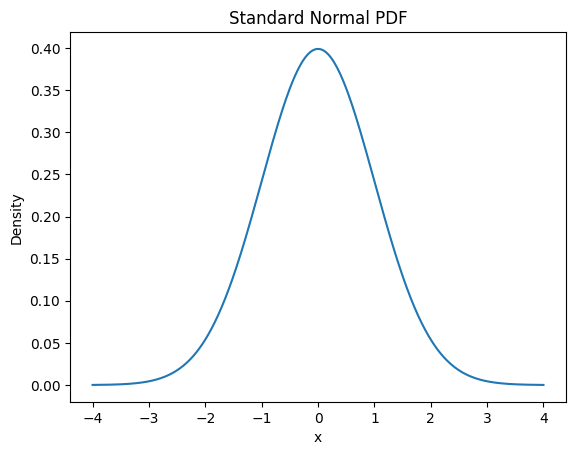

In [5]:
from scipy.stats import norm

x = np.linspace(-4, 4, 500)

pdf = norm.pdf(x, loc=0, scale=1)

plt.plot(x, pdf)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Standard Normal PDF")

plt.show()

## Probability as Area Under the PDF

For a continuous random variable:

$$
P(a\leq X\leq b)
=
\int_a^b f(x)\,dx
$$

For a standard Normal distribution, let's calculate:

$$
P(-1\leq X\leq1)
$$

In [6]:
probability = norm.cdf(1) - norm.cdf(-1)

print(f"P(-1 <= X <= 1) = {probability:.4f}")

P(-1 <= X <= 1) = 0.6827


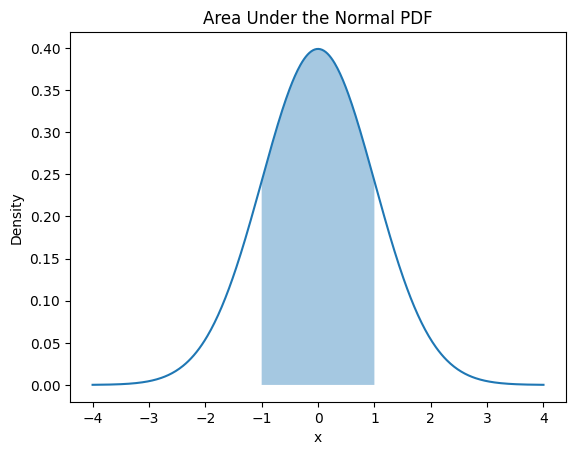

In [7]:
x_interval = np.linspace(-1, 1, 200)
y_interval = norm.pdf(x_interval)

plt.plot(x, pdf)

plt.fill_between(x_interval, y_interval, alpha=0.4)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Area Under the Normal PDF")

plt.show()

## PDF and CDF Relationship

For a continuous random variable:

$$
F(x)=\int_{-\infty}^{x}f(t)\,dt
$$

and:

$$
f(x)=\frac{d}{dx}F(x)
$$

The CDF accumulates probability from left to right.

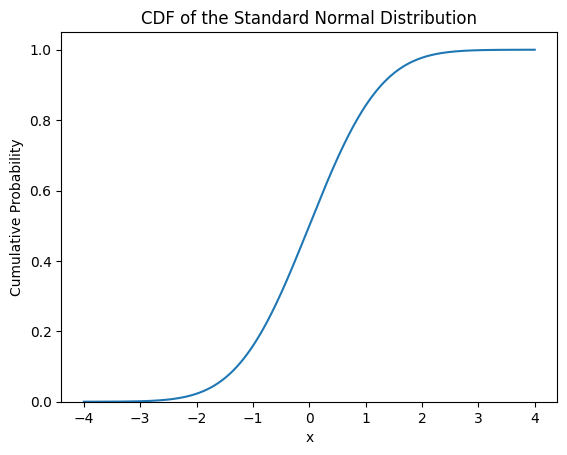

In [8]:
cdf_normal = norm.cdf(x)

plt.plot(x, cdf_normal)

plt.xlabel("x")
plt.ylabel("Cumulative Probability")
plt.title("CDF of the Standard Normal Distribution")

plt.ylim(0, 1.05)
plt.show()

## Bernoulli Distribution

A Bernoulli random variable has two possible outcomes:

$$
X\in\{0,1\}
$$

For example:

- \(1\) = Success
- \(0\) = Failure

If the probability of success is \(p=0.7\):

$$
P(X=1)=0.7
$$

$$
P(X=0)=0.3
$$

In [9]:
from scipy.stats import bernoulli

p = 0.7

x_bernoulli = np.array([0, 1])
pmf_bernoulli = bernoulli.pmf(x_bernoulli, p)

print("Values:", x_bernoulli)
print("Probabilities:", pmf_bernoulli)
print("Total probability:", pmf_bernoulli.sum())

Values: [0 1]
Probabilities: [0.3 0.7]
Total probability: 1.0


## Binomial Distribution

The Binomial distribution counts the number of successes in a fixed number of independent Bernoulli trials.

Example:

> Number of Heads in 10 coin tosses.

If:

$$
n=10,\quad p=0.5
$$

then \(X\) represents the number of heads.

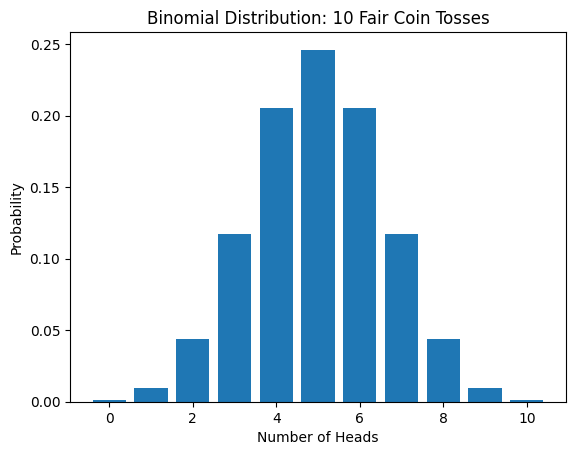

In [10]:
from scipy.stats import binom

n = 10
p = 0.5

x_binomial = np.arange(0, n + 1)
pmf_binomial = binom.pmf(x_binomial, n, p)

plt.bar(x_binomial, pmf_binomial)

plt.xlabel("Number of Heads")
plt.ylabel("Probability")
plt.title("Binomial Distribution: 10 Fair Coin Tosses")

plt.show()

## Poisson Distribution

The Poisson distribution models the number of events occurring within a fixed interval under appropriate assumptions.

Example:

> Number of emails received in an hour.

Suppose the average number of emails per hour is:

$$
\lambda=4
$$

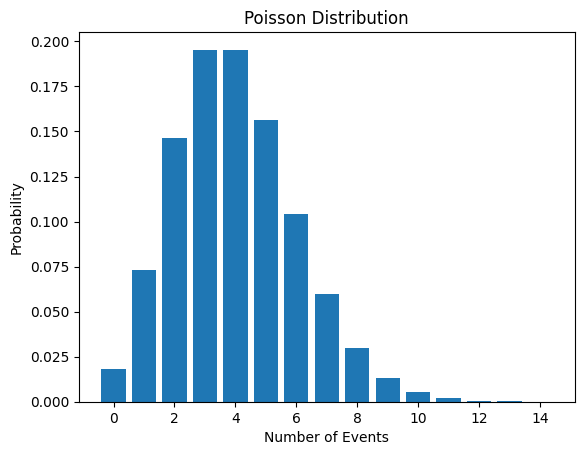

In [11]:
from scipy.stats import poisson

lambda_value = 4

x_poisson = np.arange(0, 15)
pmf_poisson = poisson.pmf(x_poisson, lambda_value)

plt.bar(x_poisson, pmf_poisson)

plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.title("Poisson Distribution")

plt.show()

## PMF vs PDF vs CDF

| Function | Main Use | What It Represents |
|---|---|---|
| PMF | Discrete variables | \(P(X=x)\) |
| PDF | Continuous variables | Probability density |
| CDF | Discrete and continuous | \(P(X\leq x)\) |

Remember:

- PMF → probability at discrete values
- PDF → density over a continuous range
- CDF → accumulated probability

## Final Summary

The key ideas from this notebook are:

1. Discrete variables can be described using a PMF.
2. Continuous variables can be described using a PDF.
3. CDFs give cumulative probability.
4. A PMF sums to 1.
5. The total area under a PDF is 1.
6. For continuous variables, probability comes from area under the PDF.
7. The PDF is the derivative of the CDF.
8. Important distributions include Bernoulli, Binomial, Normal, and Poisson.